<a href="https://colab.research.google.com/github/marstonsward/AAI-521-Computer-Vision-Image-Classification-Project/blob/main/01_data_preparation_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team Project: AI-Generated vs Real Image Classification  
**Team Members:** Marston Ward, Jasper Dolar, Victor Salcedo  
**Date:** November 5, 2025  

This project uses a convolutional neural network (CNN) and transfer learning with ResNet to classify images as AI-generated or real. The dataset is sourced directly from Hugging Face (`Hemg/AI-Generated-vs-Real-Images-Datasets`) and analyzed in Google Colab using GPU acceleration.


In [1]:
%%time
# ---------------------------------
# Cell 1: Install Required Packages
# ---------------------------------
# Standard library imports
import os
import random

# Third-party imports
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from datasets import load_dataset
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms

# 1. Determine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

Using device: cuda
CPU times: user 3.47 s, sys: 450 ms, total: 3.92 s
Wall time: 3.93 s


### Cell 2: Load Dataset from Hugging Face

In this step, we load the **AI-Generated vs Real Images** dataset directly from Hugging Face using the `load_dataset()` function.  
This dataset contains labeled images — `0` for *real* photos and `1` for *AI-generated* images.  

By printing the dataset object, we can view its available splits (such as `train`, `validation`, or `test`) and confirm that the data has been successfully loaded into the Colab environment.  
Since it’s hosted online, there’s no need to manually upload or download files; Hugging Face automatically handles caching and version control.


In [2]:
%%time
# ----------------------------------------
# Cell 3: Load Dataset from Hugging Face
# ----------------------------------------

dataset = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")

# Check available splits
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 152710
    })
})
CPU times: user 197 ms, sys: 34 ms, total: 231 ms
Wall time: 4.05 s


### Cell 4: Dataset Inspection and Class Distribution

This step explores the dataset to understand its structure and label balance.  
We first display a single sample image along with its label to verify that the dataset has loaded correctly and that each image is associated with the proper classification (`0` = Real, `1` = AI Generated).  

Next, we visualize the **class distribution** using a simple histogram.  
This helps determine whether the dataset is balanced or if one class dominates, which is important for model training and performance evaluation.  
Understanding the label distribution early on ensures that preprocessing and model design can address any imbalance if needed.


0


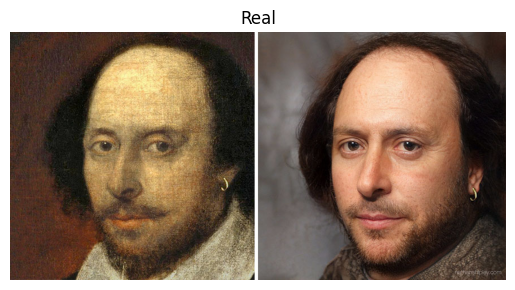

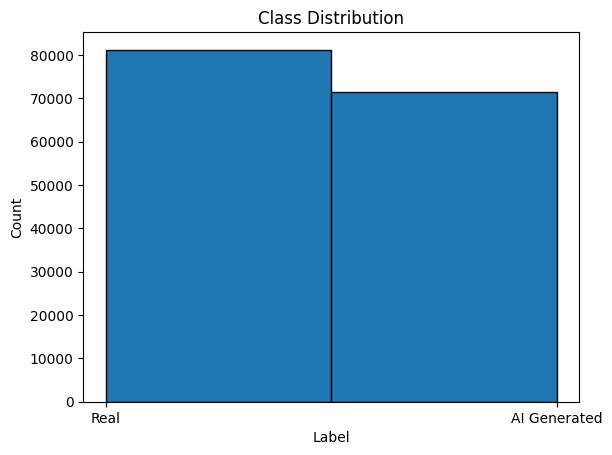

CPU times: user 1min 25s, sys: 3.41 s, total: 1min 28s
Wall time: 1min 28s


In [3]:
%%time
# ----------------------------------------
# Cell 5: Dataset Inspection and Class Distribution
# ----------------------------------------

# Inspect one sample
sample = dataset['train'][0]
print(sample['label'])
plt.imshow(sample['image'])
plt.title("AI Generated" if sample['label'] == 1 else "Real")
plt.axis('off')
plt.show()

# Class distribution
labels = [item['label'] for item in dataset['train']]
plt.hist(labels, bins=2, edgecolor='black')
plt.xticks([0,1], ['Real', 'AI Generated'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


### Cell 6: Real vs AI-Generated Image Comparison

In this step, we visualize one real image and one AI-generated image side by side for a direct comparison.  
By displaying both classes together, we can begin to notice subtle visual differences that may guide our model design — such as background smoothness, texture quality, or fine detail in features like hands or edges.  

This visual inspection provides an intuitive understanding of what distinguishes real photographs from AI-generated content and helps confirm that the labels in the dataset are accurate and meaningful before moving on to preprocessing and model training.


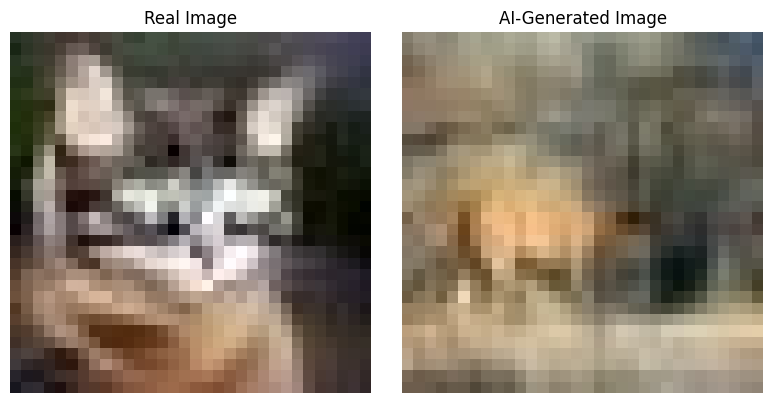

CPU times: user 2min 53s, sys: 11.2 s, total: 3min 4s
Wall time: 3min 4s


In [4]:
%%time
# ----------------------------------------
# Cell 7: Real vs AI-Generated Image Comparison
# ----------------------------------------


# Separate real and AI-generated images
real_samples = [x['image'] for x in dataset['train'] if x['label'] == 0]
fake_samples = [x['image'] for x in dataset['train'] if x['label'] == 1]

# Randomly select one from each
real_img = random.choice(real_samples)
fake_img = random.choice(fake_samples)

# Display side by side
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(real_img)
ax[0].set_title("Real Image")
ax[0].axis('off')

ax[1].imshow(fake_img)
ax[1].set_title("AI-Generated Image")
ax[1].axis('off')

plt.tight_layout()
plt.show()


### Cell 8: Image Transforms (Feature Engineering)

Here we define image transformation pipelines that prepare the data for training and evaluation.  
These transformations standardize image dimensions, improve model generalization, and match the preprocessing expected by pre-trained models such as ResNet.

For the **training set**, we include augmentation techniques — random flips, rotations, and slight color variations — to expose the model to more diverse visual examples and reduce overfitting.  
The images are resized to **224×224 pixels** (a standard input size for CNN and ResNet models), converted to tensors, and normalized using ImageNet mean and standard deviation values.

For the **validation and test sets**, we apply only resizing and normalization to ensure consistent evaluation without altering the original visual characteristics.


In [5]:
%%time
# ----------------------------------------
# Cell 9: Image Transforms (Feature Engineering)
# ----------------------------------------
# These transforms apply to both the CNN and ResNet models.
# Training set transformations: resize, augment, normalize
# The normalized mean across ImageNet is [0.485, 0.456, 0.406]
# The standard deviation across ImageNet is [0.229, 0.224, 0.225]
# These are specific ImageNet mean and standard deviation values.

height, width = 224, 224
resnet_mean = [0.485, 0.456, 0.406]
resnet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((height, width)),      # standard input size
    transforms.Lambda(lambda image: image.convert("RGB")), # Ensure 3 channels
    transforms.RandomHorizontalFlip(p=0.5),  # flip for variation
    transforms.RandomRotation(10),           # small rotations
    transforms.ColorJitter(brightness=0.1,
                           contrast=0.1,
                           saturation=0.1,
                           hue=0.05),        # small color shifts
    transforms.ToTensor(),                   # convert to tensor, scales [0,1]
    transforms.Normalize(           # normalize RGB channels (ImageNet stats)
        mean=resnet_mean,
        std=resnet_std
    )
])

# Validation / Test set transformations: resize + normalize (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.Lambda(lambda image: image.convert("RGB")), # Ensure 3 channels
    transforms.ToTensor(),
    transforms.Normalize(
        mean=resnet_mean,
        std=resnet_std
    )
])

CPU times: user 416 µs, sys: 0 ns, total: 416 µs
Wall time: 423 µs


### Cell 10: Full Dataset Split and DataLoader Preparation

This version of the data preparation step now uses the **entire dataset**.  
All available images are included, providing a more complete representation of both real and AI-generated samples for training, validation, and testing.

The dataset is shuffled to ensure randomness, then split into:
- **80%** for training  
- **10%** for validation  
- **10%** for testing  

Each split is wrapped in a PyTorch `DataLoader` for efficient batch processing.  
Using the full dataset improves model performance and generalization but also increases training time and memory usage.  
It is recommended to run this version in **Google Colab with GPU and High-RAM settings** to avoid resource limitations.


In [6]:
%%time
# ----------------------------------------------------------
# Cell 11: Dataset Wrapper, Shuffle, and Split (Full Dataset)
# ----------------------------------------------------------

# Extract images and labels
images = [x['image'] for x in dataset['train']]
labels = [x['label'] for x in dataset['train']]

# Shuffle dataset
combined = list(zip(images, labels))
random.shuffle(combined)
images, labels = zip(*combined)

# Dataset class
class HuggingFaceImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Use full dataset
subset_size = len(images)

# Split data: 80% train, 10% val, 10% test
train_end = int(0.8 * subset_size)
val_end = int(0.9 * subset_size)

train_images = images[:train_end]
val_images = images[train_end:val_end]
test_images = images[val_end:]

train_labels = labels[:train_end]
val_labels = labels[train_end:val_end]
test_labels = labels[val_end:]

# Create datasets
train_dataset = HuggingFaceImageDataset(train_images, train_labels, transform=train_transforms)
val_dataset = HuggingFaceImageDataset(val_images, val_labels, transform=val_transforms)
test_dataset = HuggingFaceImageDataset(test_images, test_labels, transform=val_transforms)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Output sizes
print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")


Train: 122168 images
Val: 15271 images
Test: 15271 images
CPU times: user 2min 52s, sys: 11.4 s, total: 3min 4s
Wall time: 3min 4s


### Cell 12: Verify DataLoader and Visualize Augmented Images

This step verifies that the DataLoader is working correctly and that the image transformations are being applied as expected.  
A batch of training images is loaded, and a sample grid of eight images is displayed after augmentation and normalization.  

The `imshow()` function reverses the normalization process so that the images appear in natural color.  
By plotting a mix of real and AI-generated samples, this visualization confirms that the data is correctly labeled, augmented, and ready for model training.  
Slight rotations, flips, and color variations seen here reflect the transformations defined earlier in the training pipeline.


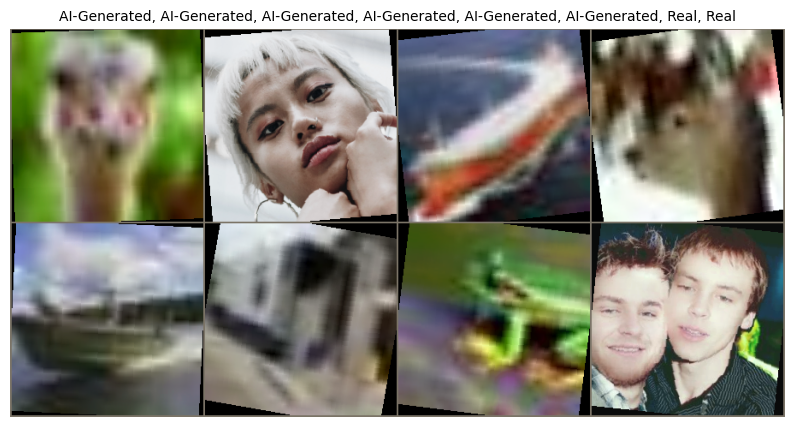

CPU times: user 1.43 s, sys: 4.17 ms, total: 1.43 s
Wall time: 526 ms


In [7]:
%%time
# ----------------------------------------
# Cell 13: Verify DataLoader and Visualize Augmented Images
# ----------------------------------------

def imshow(img):
    # Undo normalization using ImageNet stats
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # de-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

# Get one batch from DataLoader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display first 8 images
plt.figure(figsize=(10, 10))
grid = torchvision.utils.make_grid(images[:8], nrow=4, padding=2)
imshow(grid)

# Create dynamic title list
titles = ['AI-Generated' if lbl == 1 else 'Real' for lbl in labels[:8]]
plt.title(", ".join(titles), fontsize=10)
plt.show()


### Next Steps: Running the Code and Training Models (CNN and Transfer Learning)

With preprocessing complete and DataLoaders ready, your notebook is fully set up for model training and evaluation.  
Follow these steps to ensure smooth performance and consistent results.

---

#### **1. Configure the Runtime Environment**
- Open this notebook in **Google Colab**.  
- Go to **Runtime → Change runtime type → Hardware accelerator → GPU**.  
- Under **Runtime shape**, select **High-RAM** to prevent memory errors during training.  
  (Runtime → Change runtime type → Select “High-RAM” option if available.)  
- Click **Save**, then **Reconnect** when prompted.  

This setup ensures faster training and enough memory to handle the full dataset.

---

#### **2. Run All Cells in Order**
Execute each notebook cell sequentially:

1. **Cell 1 – Install Packages:** Installs all dependencies (`torch`, `torchvision`, `datasets`, `matplotlib`, etc.).  
2. **Cell 2 – Import Libraries:** Imports required modules.  
3. **Cell 3 – Load Dataset:** Loads the dataset directly from Hugging Face.  
4. **Cell 4 – Dataset Inspection:** Displays sample images and label distribution.  
5. **Cell 5 – Real vs AI-Generated Comparison:** Shows example images from each class.  
6. **Cell 6 – Image Transforms:** Defines augmentations and normalization for both CNN and ResNet models.  
7. **Cell 7 – Dataset Split and DataLoaders:** Shuffles data, splits into train/validation/test sets, and builds loaders.  
8. **Cell 8 – Verify DataLoaders:** Displays augmented training images to confirm transformations.

After running these cells, your `train_loader`, `val_loader`, and `test_loader` objects will be ready for model training.

---

# Task
Create a convolutional neural network (CNN) model for classifying images as AI-generated or real, train the model using the `train_loader`, `val_loader`, and `test_loader` across multiple epochs, and save the best performing model based on validation metrics. After training, visualize the training history (loss and accuracy curves) and evaluate the final performance of the best model on the test set. Finally, summarize the entire CNN model development process, discuss its performance, and outline potential next steps, such as exploring transfer learning with ResNet.

## Train the Model

### Subtask:
Execute the main training loop across multiple epochs. This step will orchestrate calls to the previously defined `train_epoch` and `evaluate_model` functions for each epoch. It will store training and validation loss/accuracy, print progress updates, and save the best performing model based on validation metrics. This step will utilize the existing `train_loader`, `val_loader`, and `test_loader` without recreating them.


**Reasoning**:
The first step is to define the Convolutional Neural Network (CNN) model class, instantiate it, and then define the loss function and optimizer as per the instructions. This sets up the basic components required for training.



In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=1):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # Calculate flattened features size dynamically
        # Input image size is 224x224. After 3 pooling layers (each 2x2), size becomes 224/8 = 28
        # So, the size before the first linear layer is 128 * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 28 * 28) # Flatten the tensor
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Instantiate the CNN model
model = CNN(num_classes=1).to(device)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CNN model, loss function, and optimizer defined.")

CNN model, loss function, and optimizer defined.


**Reasoning**:
The next step is to define the `train_epoch` function, which will handle one epoch of training for the CNN model. This function will iterate through the training data, perform forward and backward passes, and update model weights.



In [9]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device) # Ensure labels are float and have shape (batch_size, 1)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Calculate accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

print("train_epoch function defined.")

train_epoch function defined.


**Reasoning**:
Following the instructions, the next step is to define the `evaluate_model` function. This function is crucial for assessing the model's performance on validation and test sets without performing backpropagation.



In [10]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient calculation during evaluation
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device) # Ensure labels are float and have shape (batch_size, 1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

print("evaluate_model function defined.")

evaluate_model function defined.


**Reasoning**:
Now that the model, loss function, optimizer, and helper functions (`train_epoch`, `evaluate_model`) are defined, the next step is to implement the main training loop to train the CNN model across multiple epochs, track its performance, and save the best performing model.



In [11]:
num_epochs = 10 # Define the number of epochs
best_val_accuracy = -1.0 # Initialize with a low value
best_model_path = 'best_cnn_model.pth'

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Starting training...")

for epoch in range(num_epochs):
    # Train the model for one epoch
    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluate the model on the validation set
    val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}:\n"\
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}\n"\
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

    # Save the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model with validation accuracy: {best_val_accuracy:.4f}")

print("Training complete.")

Starting training...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10:
Train Loss: 0.5946, Train Accuracy: 0.6998
Val Loss: 0.4569, Val Accuracy: 0.7557
Saved best model with validation accuracy: 0.7557
Epoch 2/10:
Train Loss: 0.4408, Train Accuracy: 0.7684
Val Loss: 0.3475, Val Accuracy: 0.8295
Saved best model with validation accuracy: 0.8295
Epoch 3/10:
Train Loss: 0.3876, Train Accuracy: 0.8128
Val Loss: 0.3049, Val Accuracy: 0.8669
Saved best model with validation accuracy: 0.8669
Epoch 4/10:
Train Loss: 0.3550, Train Accuracy: 0.8348
Val Loss: 0.2851, Val Accuracy: 0.8870
Saved best model with validation accuracy: 0.8870
Epoch 5/10:
Train Loss: 0.3362, Train Accuracy: 0.8459
Val Loss: 0.2813, Val Accuracy: 0.8904
Saved best model with validation accuracy: 0.8904
Epoch 6/10:
Train Loss: 0.3203, Train Accuracy: 0.8551
Val Loss: 0.2847, Val Accuracy: 0.8847
Epoch 7/10:
Train Loss: 0.3115, Train Accuracy: 0.8606
Val Loss: 0.2626, Val Accuracy: 0.8975
Saved best model with validation accuracy: 0.8975
Epoch 8/10:
Train Loss: 0.3011, Train Accu

**Reasoning**:
The training loop has completed, and the training and validation losses and accuracies for each epoch have been stored. The next logical step is to visualize these metrics to understand the model's learning progress and identify potential overfitting or underfitting.



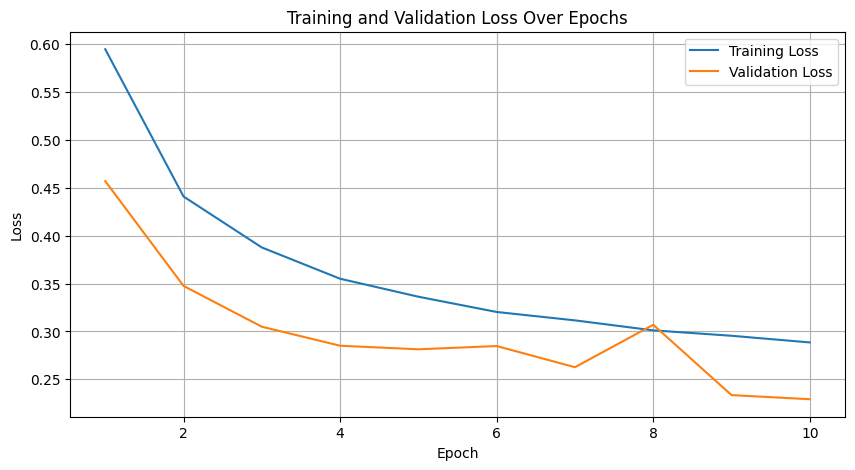

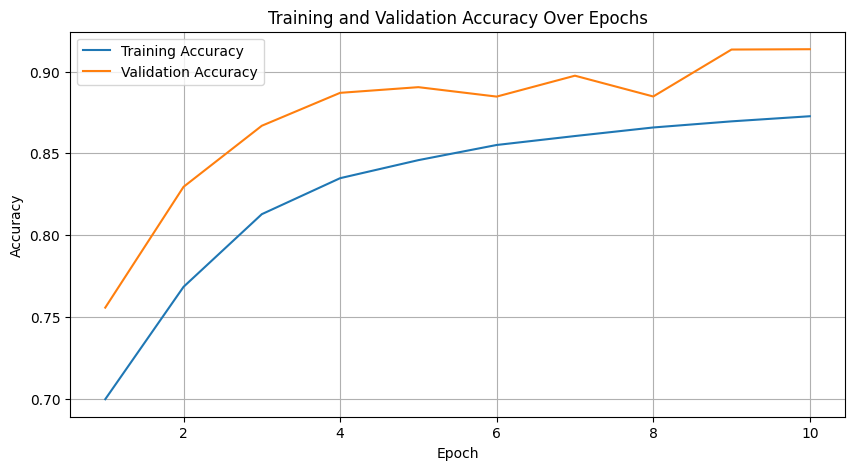

Training history plots generated.


In [12]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("Training history plots generated.")

**Reasoning**:
The previous code block failed because `num_epochs` was not defined within its scope. To fix this, `num_epochs` needs to be defined or re-accessed in the same cell where it is used for plotting. Since `num_epochs` is a scalar, simply redefining it with the value used previously will solve the `NameError`.

